# SDXL Orthographic Hallucination — Baseline & Mechanistic Experiments

This notebook implements:
- **Phase 0**: Controlled prompt suite + OCR evaluation pipeline (baseline CER/WER table)
- **Exp 1**: Text-encoding bottleneck analysis (tokenization, embedding separability, denoiser sensitivity)
- **Exp 2**: Cross-attention misbinding analysis (attention hooks, ROI statistics, scene complexity ablation)

**Runtime requirement**: GPU (T4 minimum, A100 recommended for faster generation). Enable via Runtime → Change runtime type → GPU.

---
## 0. Installation & Imports

In [69]:
# [COLAB ONLY] Dependency installation — not needed locally
# # Core torch stack — matched versions
# !pip install torch==2.5.1+cu121 torchvision==0.20.1+cu121 torchaudio==2.5.1+cu121 --index-url https://download.pytorch.org/whl/cu121 --force-reinstall

# # HuggingFace stack - show output for these critical ones
# !pip install huggingface_hub==0.25.2 transformers==4.46.1 accelerate==0.34.2 diffusers==0.31.0 peft==0.14.0 --force-reinstall
# # Other dependencies
# !pip install xformers==0.0.28.post3 --index-url https://download.pytorch.org/whl/cu121 --force-reinstall
# !pip install numpy==1.26.4 surya-ocr==0.4.3 python-Levenshtein pandas matplotlib --force-reinstall



# 1. Uninstall the current conflicting versions to clear the cache
# !pip uninstall -y torch torchvision torchaudio xformers

# 2. Install the 'Golden Trio' for Torch 2.5.1
# !pip install torch==2.5.1+cu121 torchvision==0.20.1+cu121 torchaudio==2.5.1+cu121 --index-url https://download.pytorch.org/whl/cu121

# 3. Install xformers built specifically for Torch 2.5.1
# !pip install xformers==0.0.28.post3 --index-url https://download.pytorch.org/whl/cu121

# 4. Ensure Diffusers and PEFT match this modern stack
# !pip install huggingface_hub==0.25.2 transformers==4.46.1 accelerate==0.34.2 diffusers==0.31.0 peft==0.14.0 --no-deps

In [70]:
# [COLAB ONLY] Dependency installation — not needed locally
# WORKING CELL FOR DEPENDENCIES

# 1. Clean the slate
# !pip uninstall -y torch torchvision torchaudio xformers diffusers transformers accelerate surya-ocr numpy pillow pandas

# 2. Install the "Compatibility Stack"
# We use Torch 2.4.1 + cu121 as the anchor
# !pip install numpy==1.26.4 pillow==10.3.0 pandas==2.2.2
# !pip install torch==2.4.1+cu121 torchvision==0.19.1+cu121 torchaudio==2.4.1+cu121 --index-url https://download.pytorch.org/whl/cu121

# 3. Install Surya and HF stack (forcing them to coexist)
# !pip install transformers==4.44.2 diffusers==0.30.3 accelerate==0.33.0 huggingface-hub==0.25.2 peft==0.12.0
# !pip install surya-ocr==0.4.3 --no-deps
# !pip install xformers==0.0.27.post2 --index-url https://download.pytorch.org/whl/cu121

In [71]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
from pathlib import Path
from itertools import product
from collections import defaultdict
from scipy import stats
import json, os, re

from Levenshtein import distance as levenshtein_distance

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')


Using device: cpu


In [72]:
# [COLAB ONLY] Google Drive mount
# from google.colab import drive
# drive.mount('/content/drive')

In [73]:
# Output directory (local)
OUTPUT_DIR = Path('/Users/nicoleshen/Downloads/mmai_project')
(OUTPUT_DIR / 'results').mkdir(exist_ok=True, parents=True)
print('Output directories ready.')


Output directories ready.


---
## Phase 0: Prompt Suite & Baseline Pipeline

### 0.1 Define the Factorial Prompt Suite

In [74]:
# ── Target strings across difficulty axes ──────────────────────────────────────
TARGET_STRINGS = {
    'short_common':    ['CAT', 'DOG', 'SUN'],
    'medium_common':   ['MARKET', 'BRIDGE', 'GARDEN'],
    'long_common':     ['STRAWBERRY', 'THUNDERBOLT', 'WATERMELON'],
    'digits':          ['2847', '90312', '15503'],
    'mixed_alphanum':  ['H2O', 'R2D2', 'B52'],
}

# Flatten to a list of (string, category) tuples
ALL_TARGETS = [
    (s, cat)
    for cat, strings in TARGET_STRINGS.items()
    for s in strings
]

# ── Scene complexity ───────────────────────────────────────────────────────────
SCENE_TEMPLATES = {
    'blank':    'a plain white sign with the word "{target}" printed clearly on it',
    'simple':   'a wooden storefront sign that clearly says "{target}"',
    'cluttered':'a neon sign on a busy city street that reads "{target}"',
}

# ── Prompt format variants ─────────────────────────────────────────────────────
# Each is a function that takes (scene_desc, target) and returns a full prompt
PROMPT_FORMATS = {
    'quoted':    lambda scene, t: scene.replace(f'"{t}"', f'"{t}"'),
    'unquoted':  lambda scene, t: scene.replace(f'"{t}"', t),
    'letterspaced': lambda scene, t: scene.replace(f'"{t}"', ' '.join(list(t))),
    'verbatim':  lambda scene, t: scene.replace(f'"{t}"', t) + f', render the exact characters: {t}',
}


# ── Seeds ──────────────────────────────────────────────────────────────────────
SEEDS = [42, 123]

# ── Build prompt grid ──────────────────────────────────────────────────────────
def build_prompt_grid(targets=ALL_TARGETS,
                      scenes=SCENE_TEMPLATES,
                      formats=PROMPT_FORMATS,
                      seeds=SEEDS):
    """
    Returns a list of dicts, each representing one generation job.
    For the full factorial design this can be large; we provide a
    `subset` flag to run a quick smoke-test first.
    """
    grid = []
    for (target, target_cat), (scene_name, scene_tmpl), (fmt_name, fmt_fn) in product(
        targets, scenes.items(), formats.items()
    ):
        scene_desc = scene_tmpl.format(target=target)
        prompt = fmt_fn(scene_desc, target)
        for seed in seeds:
            grid.append({
                'target':      target,
                'target_cat':  target_cat,
                'scene':       scene_name,
                'format':      fmt_name,
                'seed':        seed,
                'prompt':      prompt,
                'image_path':  None,  # filled in after generation
            })
    return grid


def build_smoke_test_grid():
    """Minimal grid for quick testing: 2 targets × 2 scenes × 1 format × 1 viewpoint × 2 seeds."""
    return build_prompt_grid(
        targets=[('MARKET', 'medium_common'), ('2847', 'digits')],
        scenes={k: SCENE_TEMPLATES[k] for k in ['blank', 'cluttered']},
        formats={k: PROMPT_FORMATS[k] for k in ['quoted']},
        seeds=[42, 123],
    )


# Choose which grid to run:
#   smoke_test_grid  → 8 images, fast, for debugging
#   full_grid        → ~360 images, use for real experiments - can increase if needed
SMOKE_TEST = False   # ← set to False for full run

prompt_grid = build_smoke_test_grid() if SMOKE_TEST else build_prompt_grid()
print(f'Prompt grid size: {len(prompt_grid)} generations')
pd.DataFrame(prompt_grid[:5])

Prompt grid size: 360 generations


,target,target_cat,scene,format,seed,prompt,image_path
0,CAT,short_common,blank,quoted,42,"a plain white sign with the word ""CAT"" printed...",None
1,CAT,short_common,blank,quoted,123,"a plain white sign with the word ""CAT"" printed...",None
2,CAT,short_common,blank,unquoted,42,a plain white sign with the word CAT printed c...,None
3,CAT,short_common,blank,unquoted,123,a plain white sign with the word CAT printed c...,None
4,CAT,short_common,blank,letterspaced,42,a plain white sign with the word C A T printed...,None


### 0.2 Load SDXL

In [75]:
# [SDXL] Model loading — commented out, images already generated
# Load SDXL base model
# fp16 + xformers keeps VRAM under 12 GB on T4
# MODEL_ID = 'stabilityai/stable-diffusion-xl-base-1.0'

# pipe = StableDiffusionXLPipeline.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.float16,
#     variant='fp16',
#     use_safetensors=True,
# )
# pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
# pipe = pipe.to(device)

# Enable memory-efficient attention if xformers is available
# try:
#     pipe.enable_xformers_memory_efficient_attention()
#     print('xformers enabled')
# except Exception:
#     print('xformers not available, using default attention')

# Fixed generation settings — never change these across experiments
# GEN_KWARGS = dict(
#     height=1024,
#     width=1024,
#     num_inference_steps=50,
#     guidance_scale=7.5,
#     negative_prompt='blurry, low quality, distorted',
# )

# print('SDXL loaded.')

### 0.3 Generate Images

In [76]:
# [SDXL] Image generation — commented out, images already generated
# def generate_image(pipe, prompt, seed, save_path=None):
#     """Generate a single image with a fixed seed and save it."""
#     generator = torch.Generator(device=device).manual_seed(seed)
#     with torch.inference_mode():
#         result = pipe(prompt=prompt, generator=generator, **GEN_KWARGS)
#     image = result.images[0]
#     if save_path:
#         image.save(save_path)
#     return image


# Run generation over the prompt grid
# Skips already-generated images so you can resume interrupted runs
# for i, entry in enumerate(prompt_grid):
#     fname = f"{entry['target']}_{entry['scene']}_{entry['format']}_seed{entry['seed']}.png"
#     save_path = OUTPUT_DIR / 'images' / fname
#     entry['image_path'] = str(save_path)

#     if save_path.exists():
#         print(f'[{i+1}/{len(prompt_grid)}] Skipping (exists): {fname}')
#         continue

#     print(f'[{i+1}/{len(prompt_grid)}] Generating: {fname}')
#     generate_image(pipe, entry['prompt'], entry['seed'], save_path=save_path)

# print('\nAll generations complete.')

### 0.4 OCR Evaluation Pipeline

In [77]:
# trocr_processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-printed')
# trocr_model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-printed').to(device)
# trocr_model.eval()
# print('TrOCR ready.')

# def run_ocr(image_path):
#     """
#     Returns list of (bbox, text, confidence) tuples
#     """
#     image = Image.open(image_path).convert('RGB')
#     pixel_values = trocr_processor(image, return_tensors='pt').pixel_values.to(device)
#     with torch.no_grad():
#         generated_ids = trocr_model.generate(pixel_values)
#     text = trocr_processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
#     if not text:
#         return []
#     # Return in same (bbox, text, confidence) format score_image expects
#     return [([[0,0],[0,0],[0,0],[0,0]], text, 1.0)]


In [78]:
# Install easyocr if not already installed:
# !pip install easyocr

In [79]:
import easyocr

ocr_reader = easyocr.Reader(['en'], gpu=torch.cuda.is_available())
print('EasyOCR ready.')

def run_ocr(image_path):
    # detail=1 returns (bbox, text, confidence) — already the format score_image expects
    results = ocr_reader.readtext(str(image_path), detail=1)
    return results if results else []


Using CPU. Note: This module is much faster with a GPU.


EasyOCR ready.


In [80]:
# ── Metric functions ───────────────────────────────────────────────────────────

def ned(detected, target):
    """Normalized Edit Distance ∈ [0, 1]. 0 = perfect match."""
    if len(detected) == 0 and len(target) == 0:
        return 0.0
    return levenshtein_distance(detected.upper(), target.upper()) / max(len(detected), len(target))

def cer(detected, target):
    """Character Error Rate = edit_distance / len(target). Can exceed 1."""
    if len(target) == 0:
        return 0.0 if len(detected) == 0 else 1.0
    return levenshtein_distance(detected.upper(), target.upper()) / len(target)

# ── Glyph normalization ───────────────────────────────────────────────────────
# Maps visually similar characters to a canonical form so both
# detected and target are compared on equal footing.
GLYPH_CANON = str.maketrans({
    '0': 'O', '1': 'I', '3': 'E', '5': 'S', '8': 'B',
    '6': 'G', '2': 'Z', 'l': 'I',   # lowercase L -> I
})

def _normalize_glyphs(s: str) -> str:
    return s.upper().translate(GLYPH_CANON)

def classify_failure(detected, target, ned_score):
    """Classify the type of orthographic hallucination."""
    if detected == '':
        return 'no_text'
    if ned_score == 0.0:
        return 'success'
    if ned_score <= 0.1:
        return 'near_miss'

    d_up = detected.upper()
    t_up = target.upper()

    # Check for character reordering (anagram) — right chars, wrong order
    if sorted(d_up) == sorted(t_up):
        return 'reorder'

    # Check for visually similar glyph substitutions using canonical normalization
    d_canon = _normalize_glyphs(detected)
    t_canon = _normalize_glyphs(target)
    if ned(d_canon, t_canon) <= 0.1:
        return 'glyph_substitution'

    # Check for anagram after glyph normalization too
    if sorted(d_canon) == sorted(t_canon):
        return 'reorder'

    if ned_score > 0.8:
        return 'garbled'
    return 'partial'

# ── Per-image OCR scoring ──────────────────────────────────────────────────────

def score_image(image_path, target, confidence_threshold=0.3):
    """
    Run OCR on an image and return a dict of metrics.
    Handles no-detection and multi-detection cases.
    """
    results = run_ocr(image_path)

    if not results:
        return {
            'detected_string': '',
            'ocr_confidence':  0.0,
            'ned':             1.0,
            'cer':             1.0,
            'success_strict':  False,
            'success_lenient': False,
            'failure_type':    'no_text',
            'n_detections':    0,
            'spurious_text':   False,
            'target_contained': False,
        }

    # Sort detections top-to-bottom, left-to-right
    results_sorted = sorted(results, key=lambda r: (r[0][0][1], r[0][0][0]))

    # Among all detections, find the one with best NED against target
    best_ned = 1.0
    best_str = ''
    best_conf = 0.0

    # Also try concatenating all detections
    concat_str = ''.join(r[1] for r in results_sorted if r[2] >= confidence_threshold)

    candidates = [(r[1], r[2]) for r in results_sorted] + [(concat_str, np.mean([r[2] for r in results_sorted]))]

    for cand_str, cand_conf in candidates:
        n = ned(cand_str, target)
        if n < best_ned:
            best_ned = n
            best_str = cand_str
            best_conf = cand_conf

    # Spurious text: any high-confidence detection that doesn't match target
    spurious = any(
        r[2] >= confidence_threshold and ned(r[1], target) > 0.5
        for r in results_sorted
    )

    # Check if target appears as a substring of any detection or the concat
    target_up = target.upper().strip()
    target_contained = (
        target_up in concat_str.upper()
        or any(target_up in r[1].upper() for r in results_sorted)
    )

    ned_score = best_ned
    # Scale lenient threshold by target length:
    #   short targets (<=3 chars) allow 0 edits, longer targets allow ~1 edit
    lenient_threshold = max(0.1, 1.0 / max(len(target), 1))

    return {
        'detected_string': best_str,
        'ocr_confidence':  float(best_conf),
        'ned':             float(ned_score),
        'cer':             float(cer(best_str, target)),
        'success_strict':  best_str.upper().strip() == target_up,
        'success_lenient': ned_score <= lenient_threshold,
        'failure_type':    classify_failure(best_str, target, ned_score),
        'n_detections':    len(results),
        'spurious_text':   spurious,
        'target_contained': target_contained,
    }

print('Metric functions defined.')


Metric functions defined.


In [81]:
# [COLAB ONLY] Download images from Google Drive — not needed locally
# !pip install gdown -q
# !gdown --folder https://drive.google.com/drive/folders/1gJetCGMfFuzJMIBsfW2PdNTWHQmezumL \
#     -O /content/sdxl_data/ --remaining-ok

In [82]:
OUTPUT_DIR = Path('/Users/nicoleshen/Downloads/mmai_project')

images = list((OUTPUT_DIR / 'images').rglob('*.png'))
print(f"Found {len(images)} images")
print(images[:3])

(OUTPUT_DIR / 'results').mkdir(parents=True, exist_ok=True)


Found 360 images
[PosixPath('/Users/nicoleshen/Downloads/mmai_project/images/R2D2_cluttered_verbatim_seed42.png'), PosixPath('/Users/nicoleshen/Downloads/mmai_project/images/90312_cluttered_unquoted_seed123.png'), PosixPath('/Users/nicoleshen/Downloads/mmai_project/images/90312_blank_unquoted_seed42.png')]


In [88]:
# to avoid regeneration
prompt_grid = build_prompt_grid()  # swap for build_prompt_grid() for full grid

for entry in prompt_grid:
    fname = f"{entry['target']}_{entry['scene']}_{entry['format']}_seed{entry['seed']}.png"
    matches = list(OUTPUT_DIR.rglob(fname))
    entry['image_path'] = str(matches[0]) if matches else None

found = sum(1 for e in prompt_grid if e['image_path'] is not None)
print(f"{found}/{len(prompt_grid)} images matched")


360/360 images matched


In [89]:
# Select the first 5 entries from prompt_grid for a quick test
test_grid_subset = prompt_grid[:5]
test_results_records = []

print(f"Running OCR evaluation on {len(test_grid_subset)} images:")

for i, entry in enumerate(test_grid_subset):
    if entry.get('image_path') is None or not Path(entry['image_path']).exists():
        print(f"  Warning: Image not found for {entry['target']} (seed {entry['seed']}). Skipping.")
        continue

    fname = Path(entry['image_path']).name
    print(f"[{i+1}/{len(test_grid_subset)}] Evaluating: {fname}")

    scores = score_image(entry['image_path'], entry['target'])
    record = {**entry, **scores}
    test_results_records.append(record)

    print(f"  Target: {entry['target']:<10} Detected: '{scores['detected_string']:<15}' "
          f"CER: {scores['cer']:.2f} NED: {scores['ned']:.2f} "
          f"Type: {scores['failure_type']} Contained: {scores['target_contained']}")

print("\n--- Test Results ---")
if test_results_records:
    test_df = pd.DataFrame(test_results_records)
    display_cols = ['target', 'scene', 'format', 'detected_string',
                    'ned', 'cer', 'failure_type', 'success_strict',
                    'success_lenient', 'target_contained', 'spurious_text']
    print(test_df[display_cols].to_string())

    test_df.to_csv(OUTPUT_DIR / 'results' / 'test_subset_scores_quick.csv', index=False)
    print(f"\nTest subset results saved to: {OUTPUT_DIR / 'results' / 'test_subset_scores_quick.csv'}")
else:
    print("No images were evaluated. Please ensure images have been generated.")


Running OCR evaluation on 5 images:
[1/5] Evaluating: CAT_blank_quoted_seed42.png


/Users/nicoleshen/miniconda3/envs/pytorch/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  Target: CAT        Detected: 'CAXTI          ' CER: 0.67 NED: 0.40 Type: partial Contained: False
[2/5] Evaluating: CAT_blank_quoted_seed123.png


/Users/nicoleshen/miniconda3/envs/pytorch/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  Target: CAT        Detected: 'CAIT           ' CER: 0.33 NED: 0.25 Type: partial Contained: False
[3/5] Evaluating: CAT_blank_unquoted_seed42.png


/Users/nicoleshen/miniconda3/envs/pytorch/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  Target: CAT        Detected: 'Cd             ' CER: 0.67 NED: 0.67 Type: partial Contained: False
[4/5] Evaluating: CAT_blank_unquoted_seed123.png


/Users/nicoleshen/miniconda3/envs/pytorch/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  Target: CAT        Detected: 'CATAT          ' CER: 0.67 NED: 0.40 Type: partial Contained: True
[5/5] Evaluating: CAT_blank_letterspaced_seed42.png
  Target: CAT        Detected: 'CAT            ' CER: 0.00 NED: 0.00 Type: success Contained: True

--- Test Results ---
  target  scene        format detected_string       ned       cer failure_type  success_strict  success_lenient  target_contained  spurious_text
0    CAT  blank        quoted           CAXTI  0.400000  0.666667      partial           False            False             False           True
1    CAT  blank        quoted            CAIT  0.250000  0.333333      partial           False             True             False          False
2    CAT  blank      unquoted              Cd  0.666667  0.666667      partial           False            False             False          False
3    CAT  blank      unquoted           CATAT  0.400000  0.666667      partial           False            False              True           True
4  

/Users/nicoleshen/miniconda3/envs/pytorch/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


In [90]:
# Run OCR evaluation over all generated images
results_records = []

for i, entry in enumerate(prompt_grid):
    if entry['image_path'] is None or not Path(entry['image_path']).exists():
        print(f'[{i+1}] Missing image, skipping: {entry["target"]}')
        continue

    scores = score_image(entry['image_path'], entry['target'])
    record = {**entry, **scores}
    results_records.append(record)

    print(f"[{i+1}/{len(prompt_grid)}] {entry['target']:15s} "
          f"scene={entry['scene']:10s} fmt={entry['format']:12s} "
          f"detected='{scores['detected_string']:15s}' "
          f"NED={scores['ned']:.2f} CER={scores['cer']:.2f} "
          f"type={scores['failure_type']} contained={scores['target_contained']}")

# Save results
results_df = pd.DataFrame(results_records)
results_df.to_csv(OUTPUT_DIR / 'results' / 'baseline_scores.csv', index=False)
print(f'\nResults saved. Shape: {results_df.shape}')

# Quick summary
print(f"\n--- Summary ---")
print(f"Strict success rate:  {results_df['success_strict'].mean():.1%}")
print(f"Lenient success rate: {results_df['success_lenient'].mean():.1%}")
print(f"Target contained:     {results_df['target_contained'].mean():.1%}")
print(f"Mean NED: {results_df['ned'].mean():.3f}")
print(f"Mean CER: {results_df['cer'].mean():.3f}")
print(f"\nFailure type distribution:")
print(results_df['failure_type'].value_counts().to_string())


/Users/nicoleshen/miniconda3/envs/pytorch/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


[1/360] CAT             scene=blank      fmt=quoted       detected='CAXTI          ' NED=0.40 CER=0.67 type=partial contained=False


/Users/nicoleshen/miniconda3/envs/pytorch/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


[2/360] CAT             scene=blank      fmt=quoted       detected='CAIT           ' NED=0.25 CER=0.33 type=partial contained=False


/Users/nicoleshen/miniconda3/envs/pytorch/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


...

/Users/nicoleshen/miniconda3/envs/pytorch/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


[358/360] B52             scene=cluttered  fmt=letterspaced detected='B5             ' NED=0.33 CER=0.33 type=partial contained=False


/Users/nicoleshen/miniconda3/envs/pytorch/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


[359/360] B52             scene=cluttered  fmt=verbatim     detected='B52            ' NED=0.00 CER=0.00 type=success contained=True
[360/360] B52             scene=cluttered  fmt=verbatim     detected='B5/            ' NED=0.33 CER=0.33 type=partial contained=False

Results saved. Shape: (360, 17)

--- Summary ---
Strict success rate:  13.6%
Lenient success rate: 36.1%
Target contained:     18.3%
Mean NED: 0.421
Mean CER: 0.531

Failure type distribution:
failure_type
partial               277
success                49
no_text                21
garbled                 6
glyph_substitution      5
near_miss               2


/Users/nicoleshen/miniconda3/envs/pytorch/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


### 0.5 Baseline Visualization

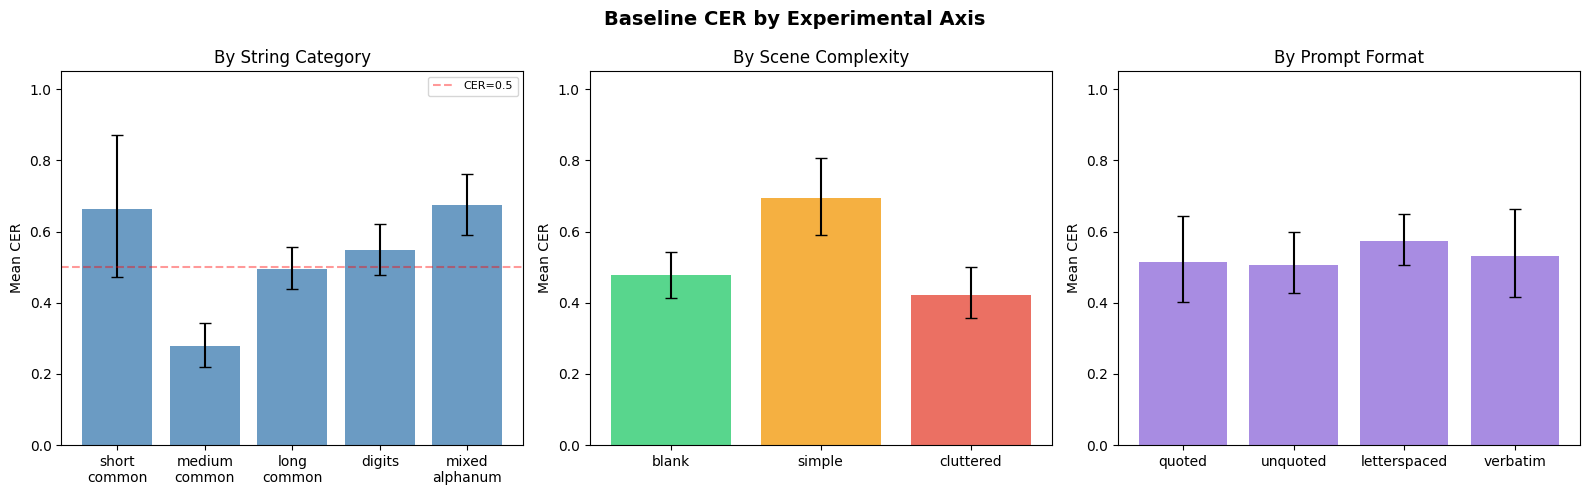

Baseline plots saved.


In [91]:
def bootstrap_ci(values, n_boot=1000, ci=95):
    """Return (mean, lower_ci, upper_ci) via bootstrapping."""
    values = np.array(values)
    boot_means = [np.mean(np.random.choice(values, size=len(values), replace=True)) for _ in range(n_boot)]
    lo = np.percentile(boot_means, (100 - ci) / 2)
    hi = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return np.mean(values), lo, hi


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Baseline CER by Experimental Axis', fontsize=14, fontweight='bold')

# ── Plot 1: CER by target category ────────────────────────────────────────────
ax = axes[0]
cat_order = ['short_common', 'medium_common', 'long_common', 'digits', 'mixed_alphanum']
cat_stats = []
for cat in cat_order:
    subset = results_df[results_df['target_cat'] == cat]['cer'].values
    if len(subset) > 0:
        mean, lo, hi = bootstrap_ci(subset)
        cat_stats.append({'cat': cat.replace('_', '\n'), 'mean': mean, 'lo': lo, 'hi': hi})

cat_df = pd.DataFrame(cat_stats)
bars = ax.bar(cat_df['cat'], cat_df['mean'], color='steelblue', alpha=0.8)
ax.errorbar(range(len(cat_df)), cat_df['mean'],
            yerr=[cat_df['mean'] - cat_df['lo'], cat_df['hi'] - cat_df['mean']],
            fmt='none', color='black', capsize=4)
ax.set_ylabel('Mean CER')
ax.set_title('By String Category')
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.4, label='CER=0.5')
ax.legend(fontsize=8)

# ── Plot 2: CER by scene complexity ───────────────────────────────────────────
ax = axes[1]
scene_stats = []
for scene in ['blank', 'simple', 'cluttered']:
    subset = results_df[results_df['scene'] == scene]['cer'].values
    if len(subset) > 0:
        mean, lo, hi = bootstrap_ci(subset)
        scene_stats.append({'scene': scene, 'mean': mean, 'lo': lo, 'hi': hi})

scene_df = pd.DataFrame(scene_stats)
colors = ['#2ecc71', '#f39c12', '#e74c3c']
ax.bar(scene_df['scene'], scene_df['mean'], color=colors, alpha=0.8)
ax.errorbar(range(len(scene_df)), scene_df['mean'],
            yerr=[scene_df['mean'] - scene_df['lo'], scene_df['hi'] - scene_df['mean']],
            fmt='none', color='black', capsize=4)
ax.set_ylabel('Mean CER')
ax.set_title('By Scene Complexity')
ax.set_ylim(0, 1.05)

# ── Plot 3: CER by prompt format ──────────────────────────────────────────────
ax = axes[2]
fmt_stats = []
for fmt in ['quoted', 'unquoted', 'letterspaced', 'verbatim']:
    subset = results_df[results_df['format'] == fmt]['cer'].values
    if len(subset) > 0:
        mean, lo, hi = bootstrap_ci(subset)
        fmt_stats.append({'fmt': fmt, 'mean': mean, 'lo': lo, 'hi': hi})

fmt_df = pd.DataFrame(fmt_stats)
ax.bar(fmt_df['fmt'], fmt_df['mean'], color='mediumpurple', alpha=0.8)
ax.errorbar(range(len(fmt_df)), fmt_df['mean'],
            yerr=[fmt_df['mean'] - fmt_df['lo'], fmt_df['hi'] - fmt_df['mean']],
            fmt='none', color='black', capsize=4)
ax.set_ylabel('Mean CER')
ax.set_title('By Prompt Format')
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'results' / 'baseline_cer_by_axis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Baseline plots saved.')

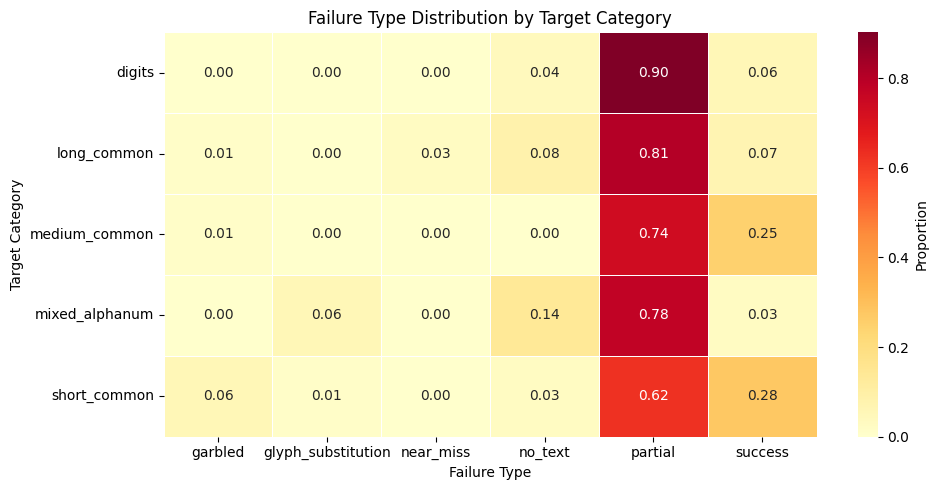

In [92]:
# Failure type distribution heatmap: rows=target_cat, cols=failure_type
failure_pivot = (
    results_df.groupby(['target_cat', 'failure_type'])
    .size()
    .unstack(fill_value=0)
)
# Normalize to proportions per row
failure_pivot_pct = failure_pivot.div(failure_pivot.sum(axis=1), axis=0)

plt.figure(figsize=(10, 5))
sns.heatmap(failure_pivot_pct, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Proportion'})
plt.title('Failure Type Distribution by Target Category')
plt.ylabel('Target Category')
plt.xlabel('Failure Type')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'results' / 'failure_type_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()